In [4]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

import tensorflow as tf
import os

# Find folder containing class directories
for root, dirs, files in os.walk('/content/dataset'):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

print("Class names:", class_names)
print("Yamini.M")
print("24BAD131")

Saving archive (1).zip to archive (1).zip
Dataset path: /content/dataset
Classes: ['train', 'val', 'train.csv', 'val.csv']
Found 345 files belonging to 2 classes.
Using 276 files for training.
Found 345 files belonging to 2 classes.
Using 69 files for validation.
Class names: ['train', 'val']
Yamini.M
24BAD131


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print("Yamini.M")
print("24BAD131")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Yamini.M
24BAD131


Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 87s 8s/step - accuracy: 0.7246 - loss: 0.8116 - val_accuracy: 0.6957 - val_loss: 0.6721
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 8s/step - accuracy: 0.8370 - loss: 0.3725 - val_accuracy: 0.7536 - val_loss: 0.6913
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.9058 - loss: 0.2623 - val_accuracy: 0.8116 - val_loss: 0.7218
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 74s 7s/step - accuracy: 0.9348 - loss: 0.1908 - val_accuracy: 0.8116 - val_loss: 0.8096
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 90s 8s/step - accuracy: 0.9819 - loss: 0.1293 - val_accuracy: 0.8116 - val_loss: 0.9349
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8116 - loss: 0.9349

FINAL RESULTS
Training Accuracy: 98.19 %
Validation Accuracy: 81.16 %
Training Loss: 0.1293
Validation Loss: 0.9349
Test Accuracy: 81.16 %


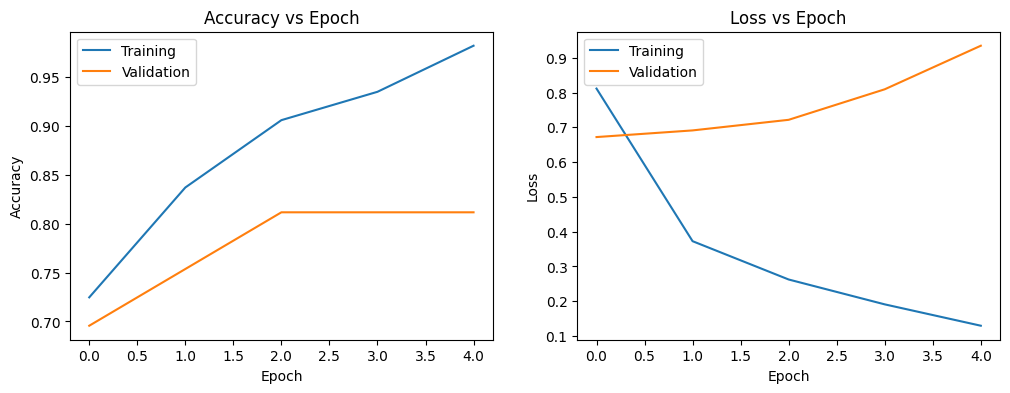

Yamini.M
24BAD131


In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

loss, accuracy = model.evaluate(val_ds)

print("\nFINAL RESULTS")
print("Training Accuracy:",
      round(history.history["accuracy"][-1] * 100, 2), "%")
print("Validation Accuracy:",
      round(history.history["val_accuracy"][-1] * 100, 2), "%")
print("Training Loss:",
      round(history.history["loss"][-1], 4))
print("Validation Loss:",
      round(history.history["val_loss"][-1], 4))
print("Test Accuracy:",
      round(accuracy * 100, 2), "%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()
print("Yamini.M")
print("24BAD131")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Prediction:
{'label': 'miniature pinscher', 'score': 0.8862519860267639}

ResNet50 Prediction:
train
Confidence: 76.92 %


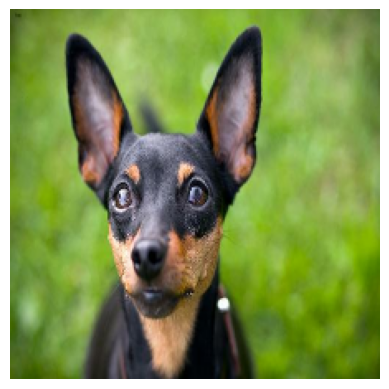

Yamini.M
24BAD131


In [7]:
!pip install -q transformers

from transformers import pipeline

classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

from PIL import Image
import numpy as np

# Get one image from the validation dataset
images, labels = next(iter(val_ds))

image = Image.fromarray(
    images[0].numpy().astype("uint8")
)

# Hugging Face prediction
hf_result = classifier(image)

print("Hugging Face Prediction:")
print(hf_result[0])

# ResNet50 prediction
resnet_result = model.predict(
    np.expand_dims(images[0].numpy(), axis=0),
    verbose=0
)

predicted_class = class_names[np.argmax(resnet_result)]

print("\nResNet50 Prediction:")
print(predicted_class)
print("Confidence:",
      round(np.max(resnet_result) * 100, 2), "%")

plt.imshow(image)
plt.axis("off")
plt.show()
print("Yamini.M")
print("24BAD131")